In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import PchipInterpolator

In [2]:
plt.rcParams.update({
    "font.family": "Optima",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [3]:

RESULT_DIR = Path('results/run_20260903_170728_epoch_23')
if not RESULT_DIR.exists():
    RESULT_DIR = Path('experiments') / RESULT_DIR
nmse_sources = pd.read_csv(RESULT_DIR / 'nmse_by_sampling_and_source.csv')
mixture_nmse = (nmse_sources.groupby('mixture_id', as_index=False)
    .agg(K=('K', 'first'), snr_gap=('snr_gap', 'first'),
         frequency_overlap=('frequency_overlap', 'first'),
         frequency_overlap_pairwise=('frequency_overlap_pairwise', 'first'),
         nmse=('nmse', 'mean')))
print(f'{len(mixture_nmse):,} mixtures, {len(nmse_sources):,} source samplings')
mixture_nmse.head()

10,000 mixtures, 551,560 source samplings


,mixture_id,K,snr_gap,frequency_overlap,frequency_overlap_pairwise,nmse
0,0,9,40.898075,0.961905,0.291393,0.230956
1,1,6,45.316545,0.924541,0.374325,0.175768
2,2,9,61.908457,0.876068,0.285509,0.172410
3,3,3,41.348800,0.783394,0.524786,0.107515
4,4,9,76.589012,0.872179,0.223084,0.096780


In [4]:
REPORT_INK = '#253047'
REPORT_GRID = '#DDE3EA'
CURVE_COLORS = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
                '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']
PLOT_STYLE = {
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#CBD2DC', 'axes.labelcolor': REPORT_INK,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
}

def clean_axis(ax):
    ax.grid(axis='y', color=REPORT_GRID, linewidth=0.8)
    ax.grid(axis='x', color='#EEF2F6', linewidth=0.6)
    ax.tick_params(axis='both', length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_curves_by_k(data, feature, edges, xlabel, title, min_samples=10, percent_x=False, skip_first_k = True):
    centers = 0.5 * (edges[:-1] + edges[1:])
    with plt.rc_context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(7.2, 6.0), dpi=180)
        for color, k in zip(CURVE_COLORS, sorted(data.K.unique())):
            if k == 1 and skip_first_k == True:
                continue
            subset = data[data.K == k]
            bin_id = pd.cut(subset[feature], edges, labels=False, include_lowest=True)
            grouped = subset.assign(bin_id=bin_id).groupby('bin_id').nmse.agg(['mean', 'size'])
            values = np.full(len(centers), np.nan)
            valid_rows = grouped[grouped['size'] >= min_samples]
            values[valid_rows.index.astype(int)] = valid_rows['mean']
            valid = np.isfinite(values)
            x, y = centers[valid], values[valid]
            if len(x) >= 3:
                smooth_x = np.linspace(x.min(), x.max(), 250)
                ax.plot(smooth_x, PchipInterpolator(x, y)(smooth_x), color=color,
                        linewidth=2.25, solid_capstyle='round', label=f'K = {k}')
                ax.scatter(x, y, color=color, s=25, zorder=3, edgecolor='white', linewidth=0.7)
            elif len(x):
                ax.plot(x, y, color=color, linewidth=2.25, marker='o', label=f'K = {k}')
        ax.set_xlabel(xlabel); ax.set_ylabel('NMSE'); ax.set_title(title, pad=10)
        clean_axis(ax)
        if percent_x: ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.legend(ncol=2, frameon=True, framealpha=0.92, facecolor='white',
                  edgecolor='none', columnspacing=1.1, handlelength=2.0)
        fig.tight_layout(); plt.show()

## 1. NMSE as a function of K

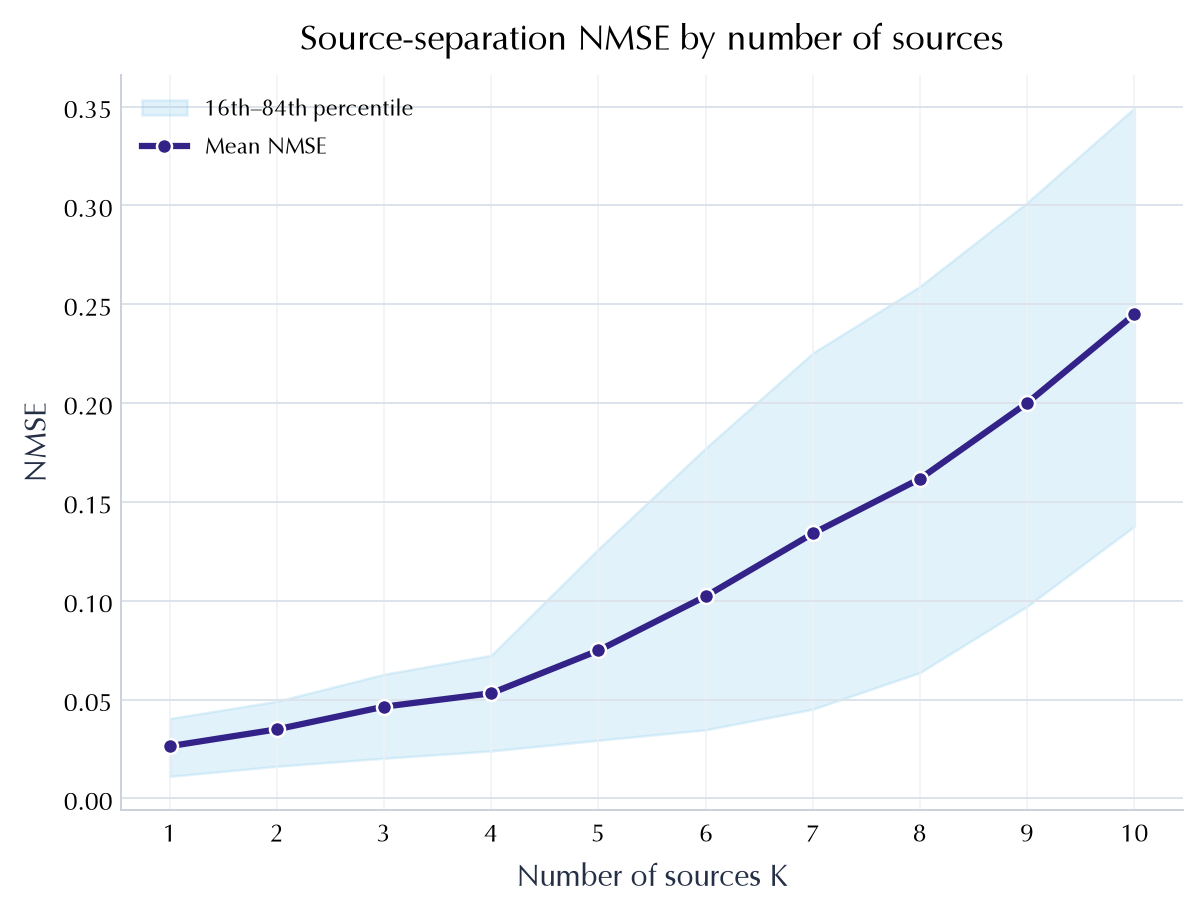

,mean,median,count
K,,,
1,0.026418,0.019458,981
2,0.034939,0.027473,984
3,0.046414,0.031674,1016
4,0.053201,0.036431,1034
5,0.074833,0.047316,947
6,0.102236,0.068954,1036
7,0.134016,0.104322,985
8,0.161711,0.138398,990
9,0.200029,0.181990,1013


In [5]:
summary_k = mixture_nmse.groupby('K').nmse.agg(['mean', 'median', 'count'])
q16 = mixture_nmse.groupby('K').nmse.quantile(0.16)
q84 = mixture_nmse.groupby('K').nmse.quantile(0.84)
with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.8, 5.2), dpi=180)
    ax.fill_between(summary_k.index, q16, q84, color='#88CCEE', alpha=0.25, label='16th–84th percentile')
    ax.plot(summary_k.index, summary_k['mean'], color='#332288', marker='o',
            linewidth=2.5, markeredgecolor='white', label='Mean NMSE')
    ax.set_xticks(summary_k.index); ax.set_xlabel('Number of sources K'); ax.set_ylabel('NMSE')
    ax.set_title('Source-separation NMSE by number of sources', pad=10)
    clean_axis(ax); ax.legend(frameon=False); fig.tight_layout(); plt.show()
summary_k

## 2a. NMSE as a function of source SNR gap

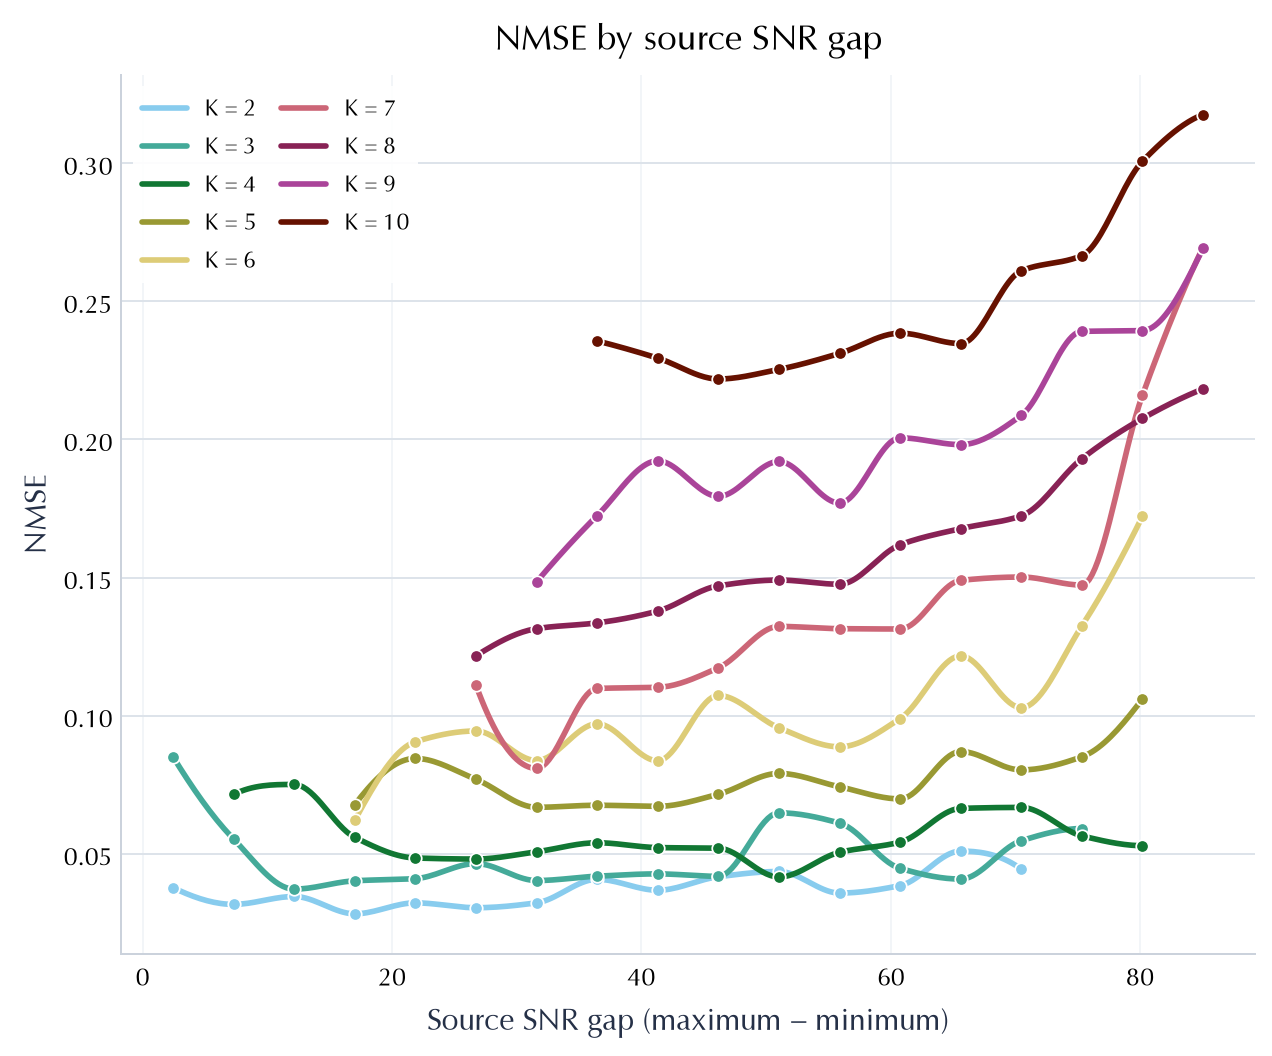

In [6]:
snr_edges = np.linspace(0.0, mixture_nmse.snr_gap.max(), 19)
plot_curves_by_k(mixture_nmse, 'snr_gap', snr_edges,
                 'Source SNR gap (maximum − minimum)', 'NMSE by source SNR gap')

## 2b. NMSE as a function of frequency overlap

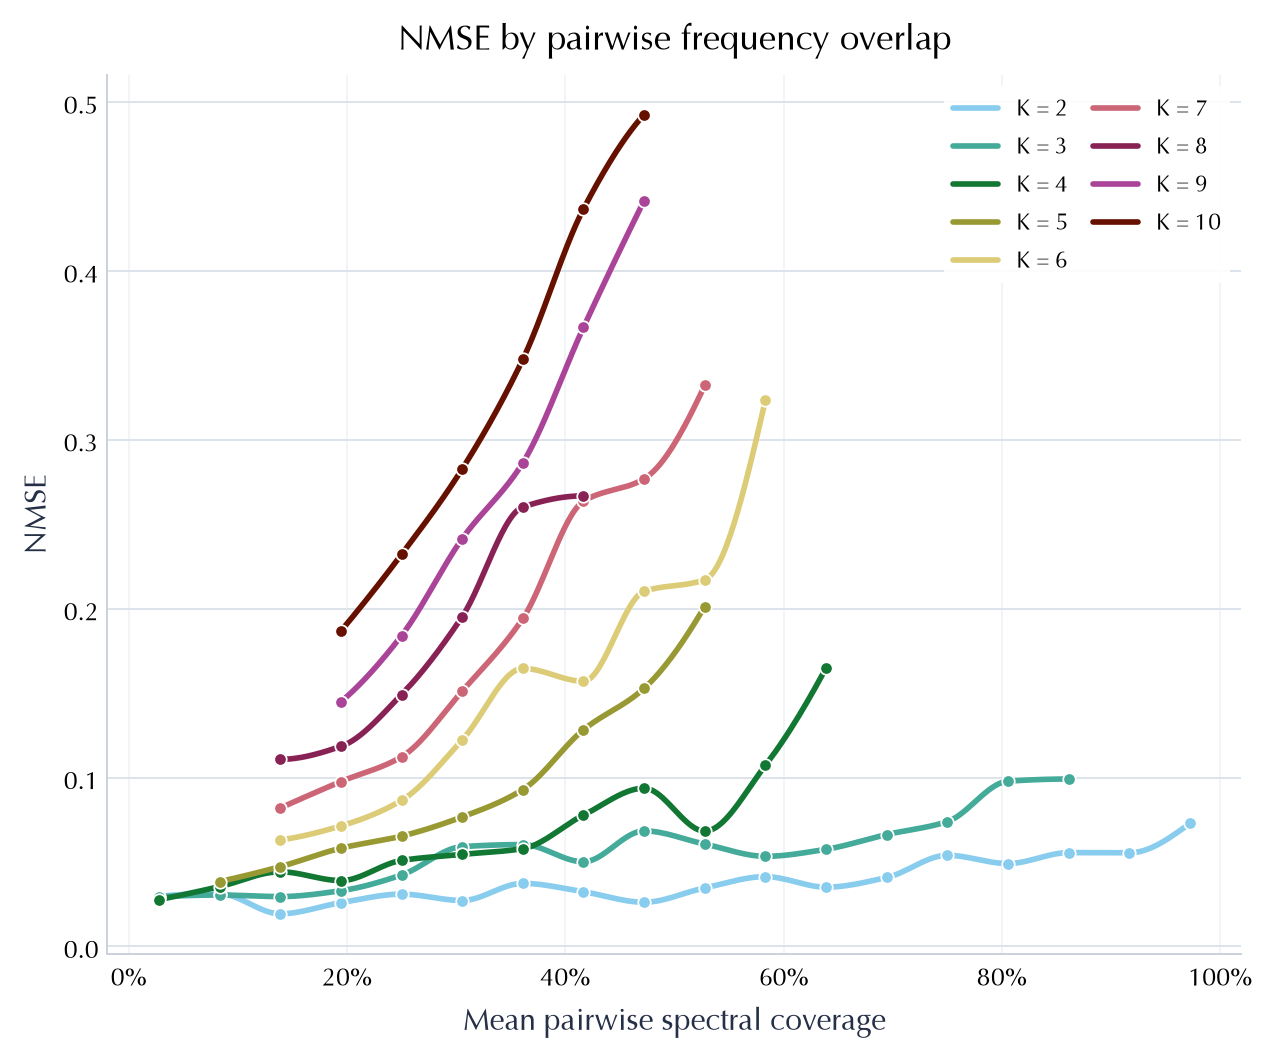

In [7]:
overlap_edges = np.linspace(0.0, 1.0, 19)
plot_curves_by_k(mixture_nmse, 'frequency_overlap_pairwise', overlap_edges,
                 'Mean pairwise spectral coverage', 'NMSE by pairwise frequency overlap', percent_x=True)

## 2c. NMSE as a function of source SNR

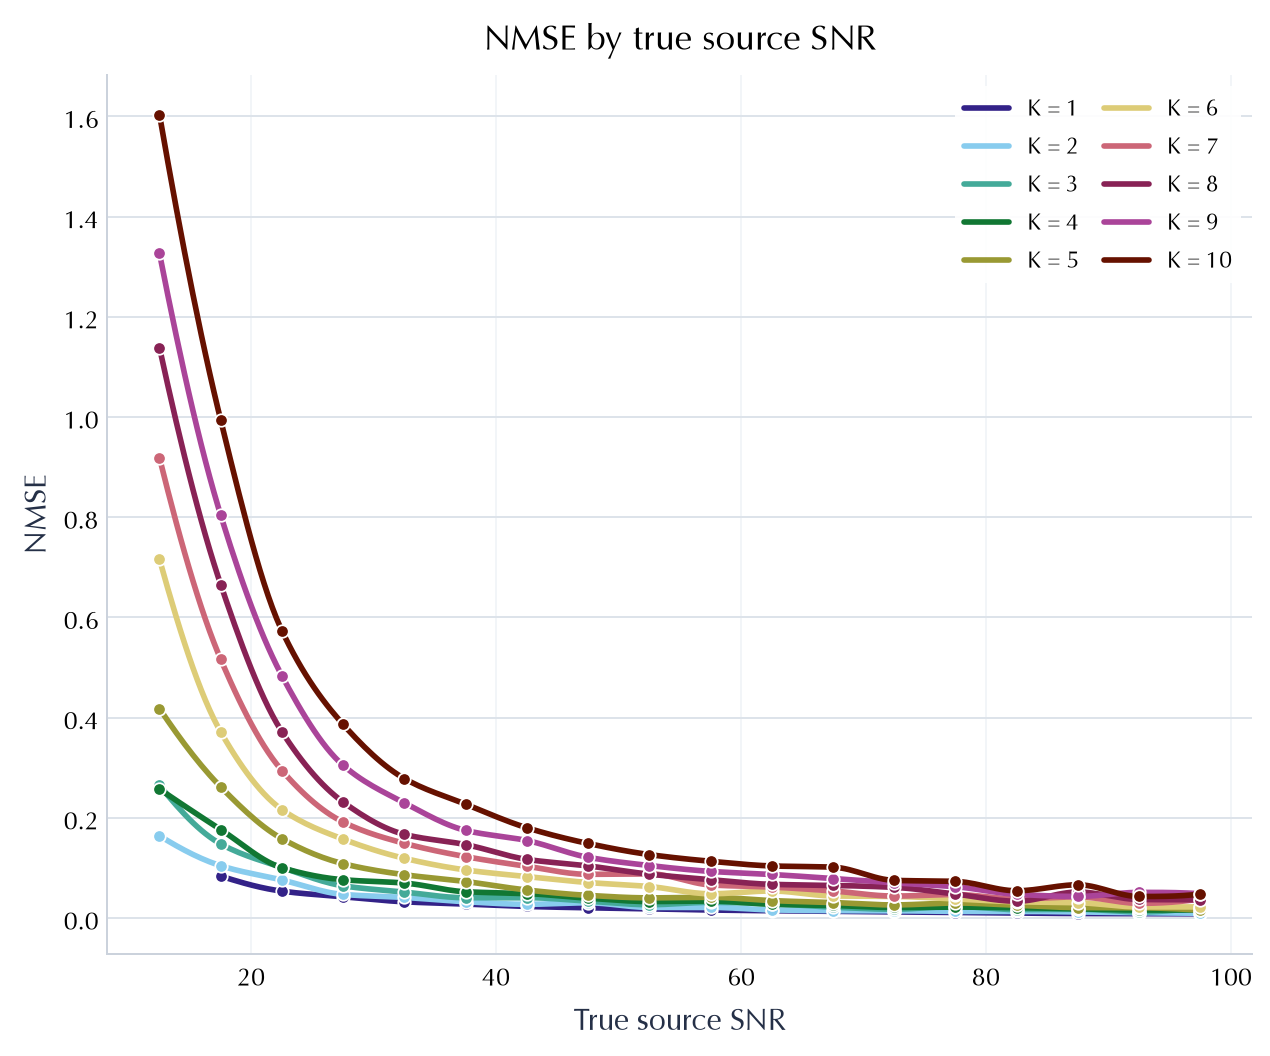

In [8]:
source_nmse = (nmse_sources.groupby(['mixture_id', 'source'], as_index=False)
    .agg(K=('K', 'first'), snr=('snr', 'first'), nmse=('nmse', 'mean')))
source_snr_edges = np.linspace(source_nmse.snr.min(), source_nmse.snr.max(), 19)
plot_curves_by_k(source_nmse, 'snr', source_snr_edges,
                 'True source SNR', 'NMSE by true source SNR', skip_first_k = False)

## 2d. NMSE by source SNR and frequency overlap

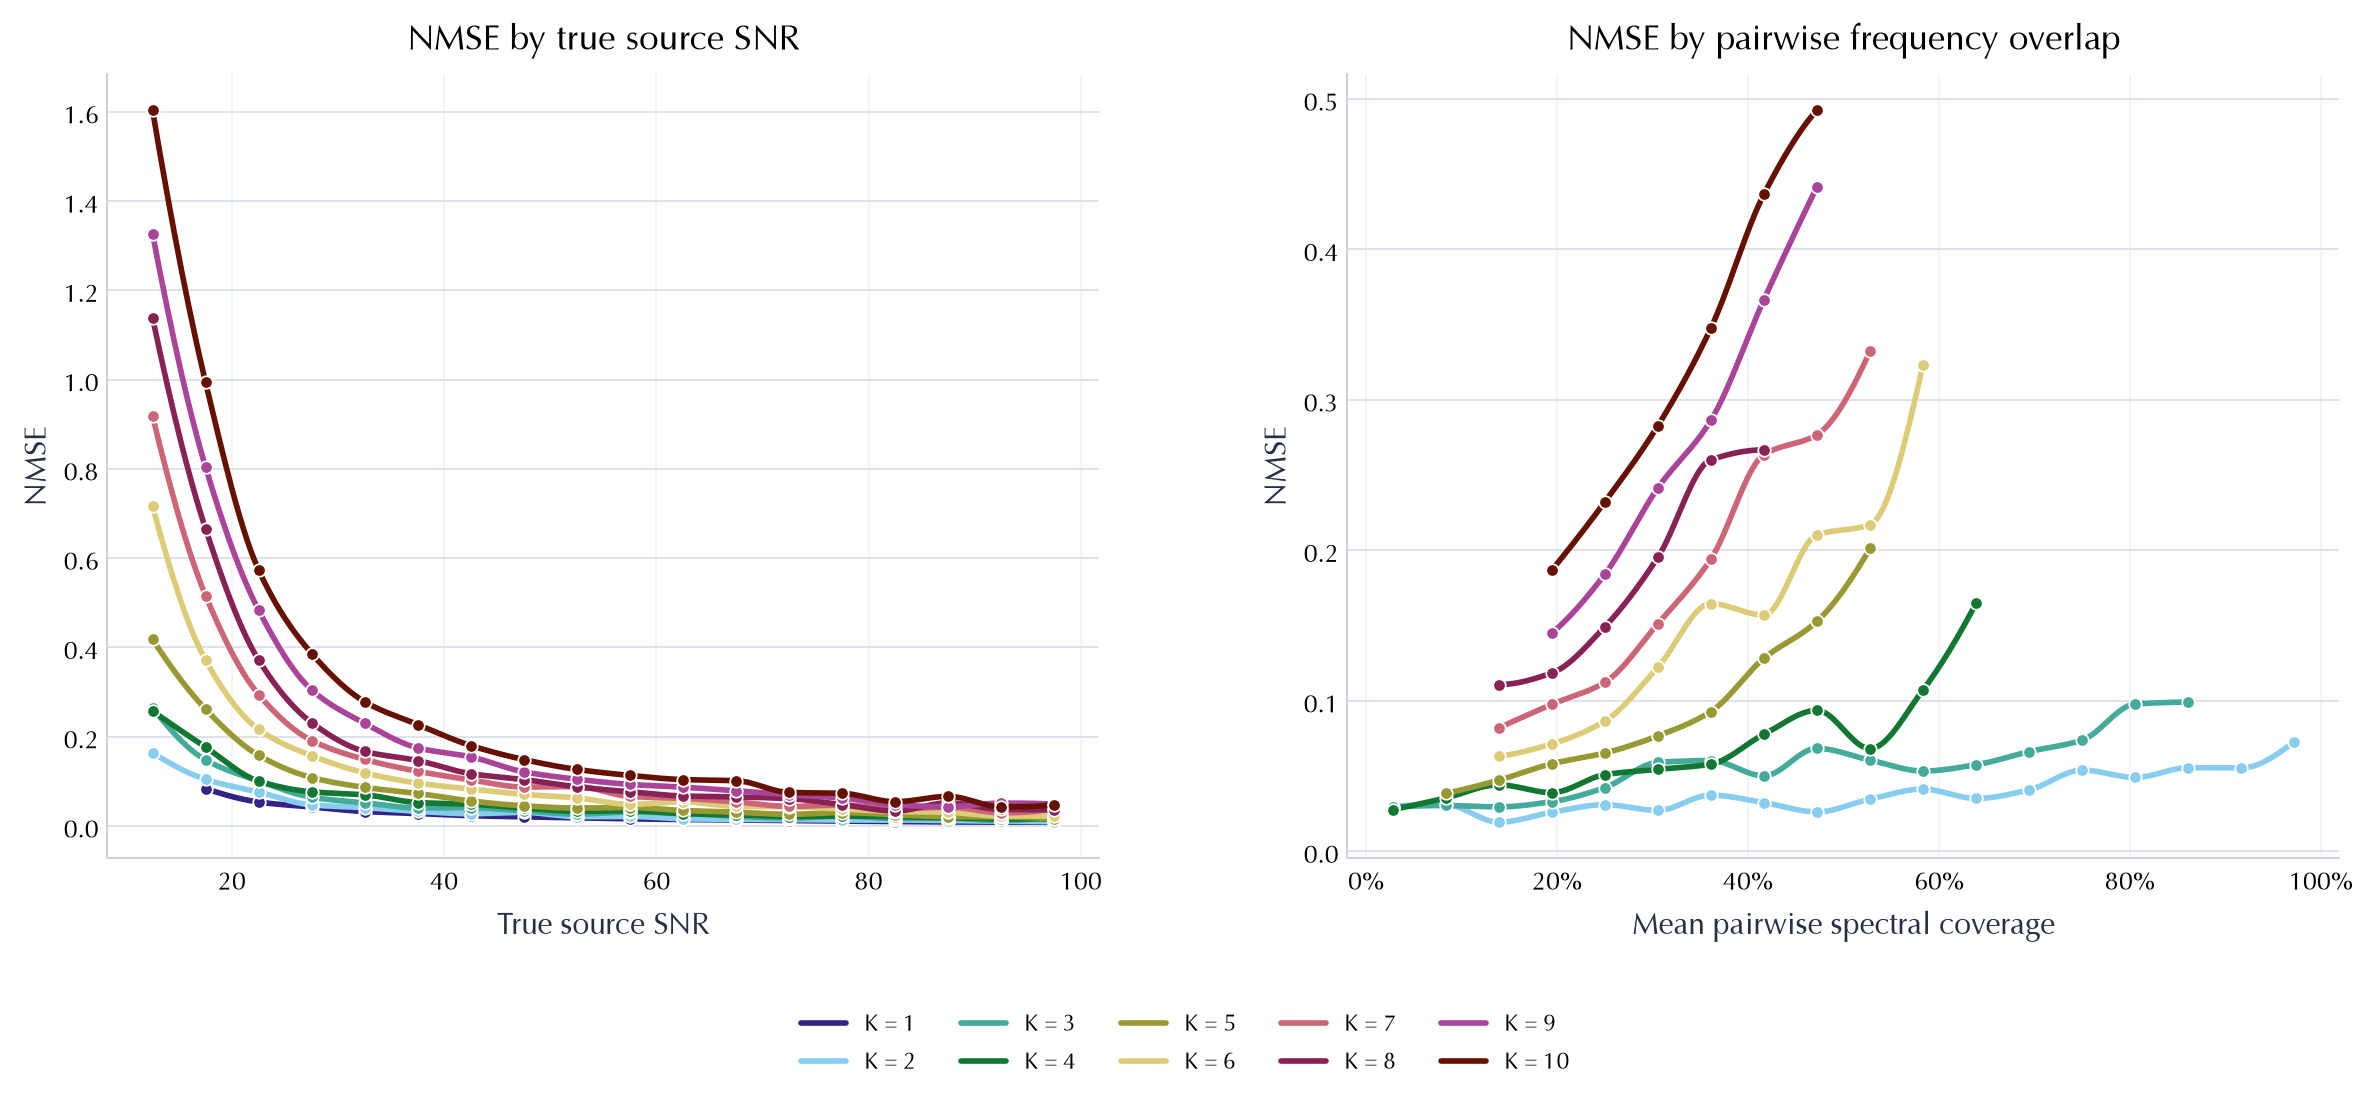

In [9]:
def add_nmse_curves_by_k(ax, data, feature, edges, min_samples=10, skip_first_k=False):
    centers = 0.5 * (edges[:-1] + edges[1:])
    for color, k in zip(CURVE_COLORS, sorted(data.K.unique())):
        if skip_first_k and k == 1:
            continue
        subset = data[data.K == k]
        bin_id = pd.cut(subset[feature], edges, labels=False, include_lowest=True)
        grouped = subset.assign(bin_id=bin_id).groupby('bin_id').nmse.agg(['mean', 'size'])
        values = np.full(len(centers), np.nan)
        valid_rows = grouped[grouped['size'] >= min_samples]
        values[valid_rows.index.astype(int)] = valid_rows['mean']
        valid = np.isfinite(values)
        x, y = centers[valid], values[valid]
        if len(x) >= 3:
            smooth_x = np.linspace(x.min(), x.max(), 250)
            ax.plot(smooth_x, PchipInterpolator(x, y)(smooth_x), color=color,
                    linewidth=2.25, solid_capstyle='round', label=f'K = {k}')
            ax.scatter(x, y, color=color, s=25, zorder=3, edgecolor='white', linewidth=0.7)
        elif len(x):
            ax.plot(x, y, color=color, linewidth=2.25, marker='o', label=f'K = {k}')
    clean_axis(ax)

with plt.rc_context(PLOT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.4), dpi=180)
    add_nmse_curves_by_k(axes[0], source_nmse, 'snr', source_snr_edges)
    axes[0].set_xlabel('True source SNR'); axes[0].set_ylabel('NMSE')
    axes[0].set_title('NMSE by true source SNR', pad=10)

    add_nmse_curves_by_k(axes[1], mixture_nmse, 'frequency_overlap_pairwise',
                         overlap_edges, skip_first_k=True)
    axes[1].set_xlabel('Mean pairwise spectral coverage'); axes[1].set_ylabel('NMSE')
    axes[1].set_title('NMSE by pairwise frequency overlap', pad=10)
    axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, frameon=False)
    fig.subplots_adjust(bottom=0.20, wspace=0.25)
    plt.show()